<a href="https://colab.research.google.com/github/beecall17/Fuse-AI-Fellowship/blob/main/Image%20Processing%20%5BWeek%2010%5D/Image_Processing_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A — Color Space & Fruit Segmentation


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


In [25]:
print(f"Open cv version:", cv2.__version__)
print(f"Numpy version:",np.__version__)

Open cv version: 4.13.0
Numpy version: 2.0.2


In [26]:
# Image plot Helper function --
def plot_images(images, titles=None, figsize=None, cmap='gray'):
    """
    Plots a list of images side by side.

    Args:
        images (list): A list of 2D orimages.
        titles (list, optional): A list of str 3D numpy arrays representing ings for subplot titles.
                                 Defaults to None.
        figsize (tuple, optional): Figure size (width, height) in inches.
                                   If None, it's calculated automatically.
                                   Defaults to None.
        cmap (str, optional): Colormap for displaying images. Defaults to 'gray'.
                              Set to None for Matplotlib to infer for RGB/RGBA images.

    Returns:
        tuple: (matplotlib.figure.Figure, matplotlib.axes.Axes or list of Axes)
               The figure and axes objects of the plot.
    """
    num_images = len(images)

    if figsize is None:
        # Dynamically adjust figure size based on the number of images
        # Assuming each image takes roughly 5x5 inches for a good display
        figsize = (num_images * 5, 5) # Width is num_images * 5, height is 5

    fig, ax = plt.subplots(1, num_images, figsize=figsize)

    # Ensure ax is always iterable, even for a single image
    if num_images == 1:
        ax = [ax]

    for i in range(num_images):
        ax[i].imshow(images[i], cmap=cmap)
        if titles is not None and i < len(titles):
            ax[i].set_title(titles[i])
        ax[i].axis('off')

    plt.tight_layout()
    plt.show()



1. Load red_apple.jpg in BGR using cv2.imread(). Display
it correctly in Matplotlib (convert to RGB first). Then display the raw BGR
version. What do you notice about the colors?

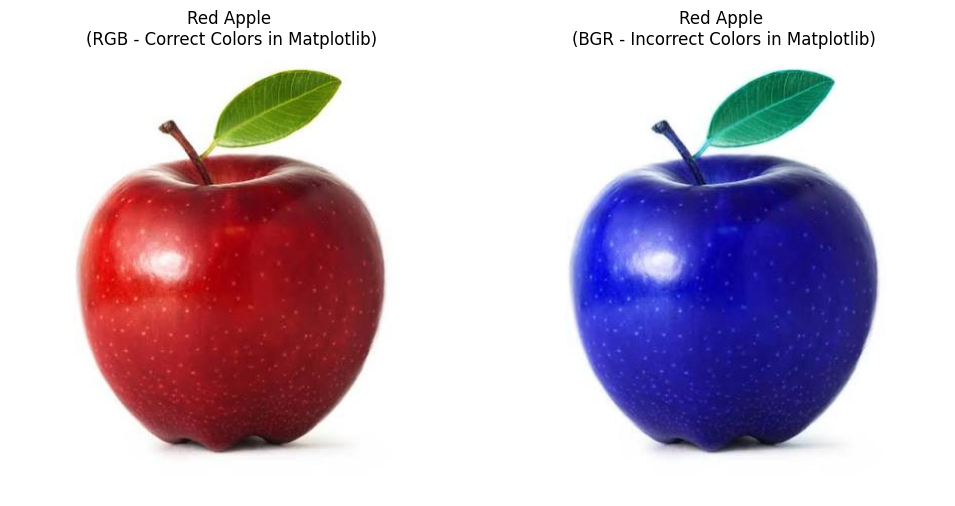

In [27]:
# Image loaded
red_apple_img = cv2.imread("/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/red_apple.jpg")
assert red_apple_img is not None, "file could not be read, check with os.path.exists()"

# BGR TO RBG
red_apple_rgb = cv2.cvtColor(red_apple_img, cv2.COLOR_BGR2RGB)

plot_images(images=[red_apple_rgb, red_apple_img],
            titles=["Red Apple \n(RGB - Correct Colors in Matplotlib)",
                    "Red Apple \n(BGR - Incorrect Colors in Matplotlib)"])

* OpenCV uses BGR format, so without converting to RGB first, the blue and red colors are swapped
* After applying BGR2RBG, the matplotlib correctly displays the original image.

In [28]:
print(f"red_apple_img.shape: {red_apple_img.shape}")
print(f"red_apple_img.dtype: {red_apple_img.dtype}")

red_apple_img.shape: (447, 447, 3)
red_apple_img.dtype: uint8


* The red apple image is of 447,447 height and width with 3 color channels.

2. Convert red_apple.jpg to HSV. Visualize the H, S, and V
channels side by side as grayscale images.

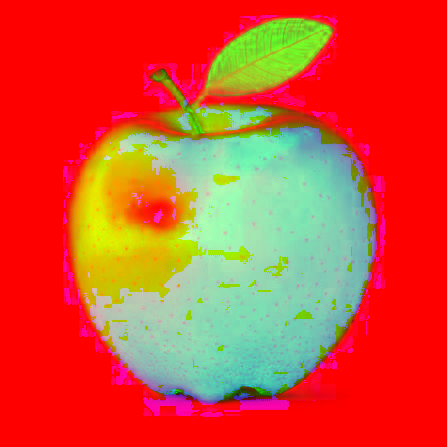

In [29]:
red_apple_hsv = cv2.cvtColor(red_apple_img, cv2.COLOR_BGR2HSV)
cv2_imshow(red_apple_hsv)

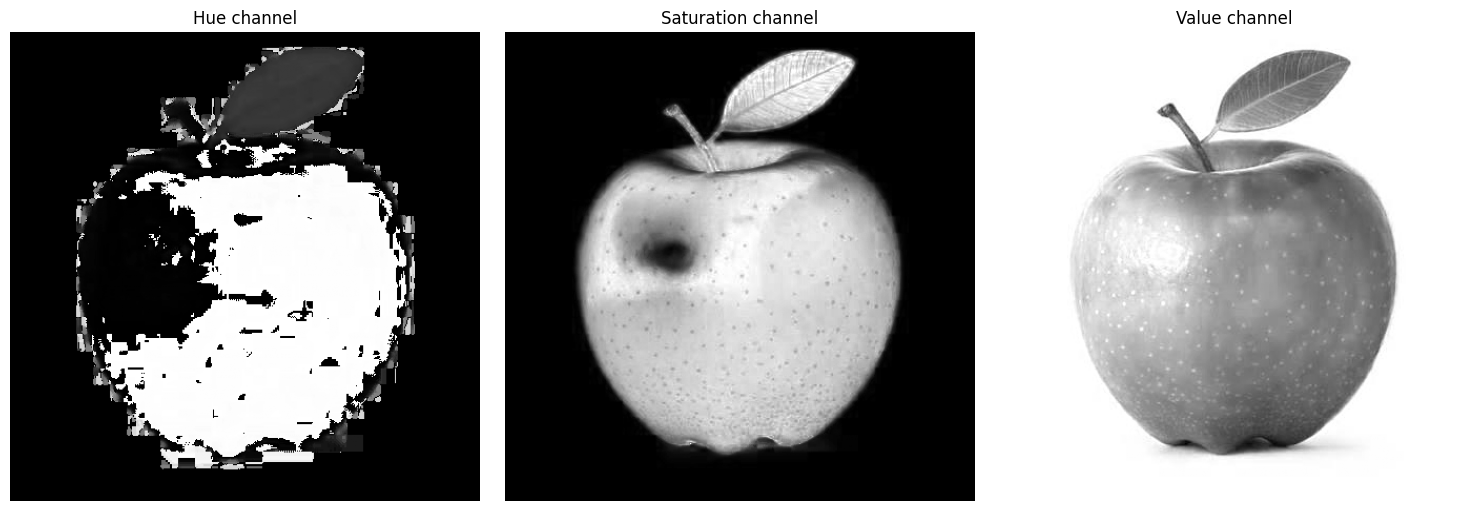

In [30]:
# Splitting h, s, v from red apple converted to hsv
h, s, v = cv2.split(red_apple_hsv)

# Visualize the h, s, v split images
plot_images(images=[h,s,v],
            titles=["Hue channel", "Saturation channel", "Value channel"])

Which channel best separates the
fruit from its white background?
> **Hue** - shows the color but the figure itself is not that clear on seperation with background.
>
> **Saturation** - the eges are seperated well from the background. The area where the light was shiny (from original), shows the deep like a rotten piece but in actual it might be deu to lighting.
>
> **Value** - the image is well seperated from white background, the image / freshness of fruit can be seen clearly as well. `V channel` is the most well seperated among all.

**Color table task:**

| Fruit       | H_min | H_max | S_min | S_max | V_min | V_max |
|:------------|:------|:------|:------|:------|:------|:------|
| `red_apple.jpg` (Lower) | 0     | 10    | 70    | 255   | 70    | 255   |
| `red_apple.jpg` (Upper) | 170   | 180   | 70    | 255   | 70    | 255   |
| `green_apple.jpg` | 35    | 85    | 50    | 255   | 50    | 255   |
| `banana.jpg`    | 20    | 35    | 50    | 255   | 50    | 255   |
| `lime.jpg`      | 25    | 60    | 50    | 255   | 50    | 255   |


3. Masking by color: use cv2.inRange() in HSV to isolate
the red apple. Red wraps around the Hue axis (0–10 and 170–180). Create two
masks and combine with cv2.bitwise_or(). Display: original | mask | masked
result.

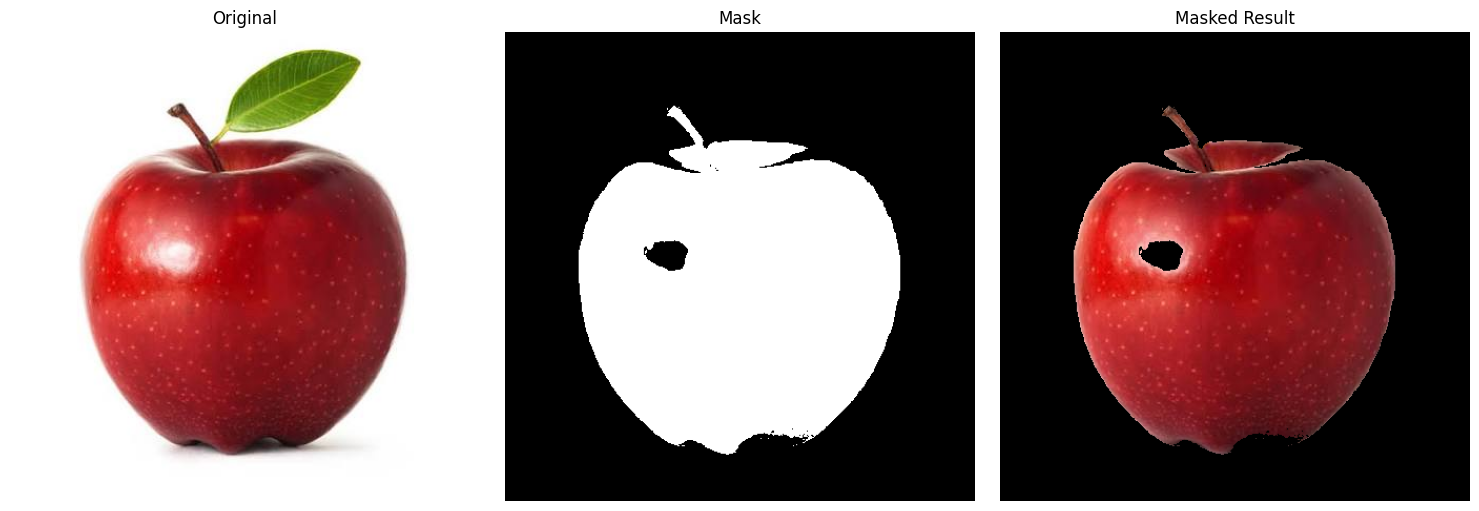

In [31]:
# HSV Masking for red apple

# Lower mask
mask1_lower_red = np.array([0,70,70])
mask1_upper_red = np.array([10,255,255])
mask1 = cv2.inRange(red_apple_hsv, mask1_lower_red, mask1_upper_red)

mask2_lower_red = np.array([170,70,70])
mask2_upper_red = np.array([180,255,255])
mask2 = cv2.inRange(red_apple_hsv, mask2_lower_red, mask2_upper_red)

mask = cv2.bitwise_or(mask1, mask2)

result_mask_red_apple = cv2.bitwise_and(red_apple_rgb, red_apple_rgb, mask=mask)

plot_images(images=[red_apple_rgb, mask, result_mask_red_apple],
            titles=["Original", "Mask", "Masked Result"])

4. Repeat the HSV masking for
green_apple.jpg, banana.jpg, and lime.jpg.


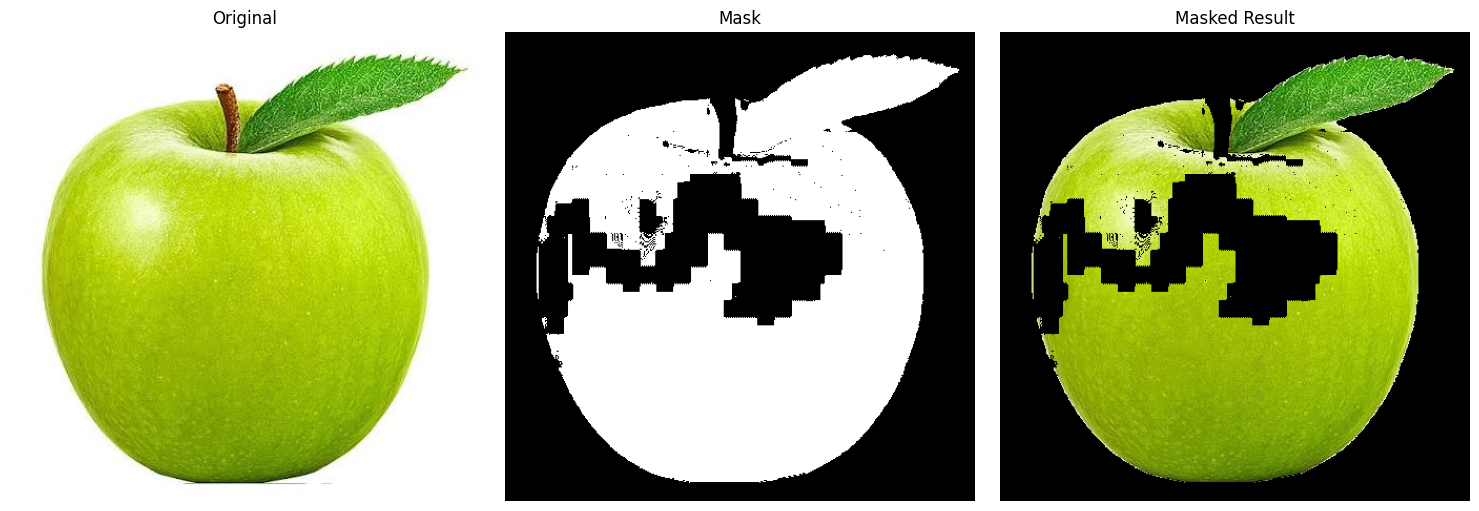

In [32]:
green_apple = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/green_apple.jpg')

green_apple_rgb = cv2.cvtColor(green_apple, cv2.COLOR_BGR2RGB)
green_apple_hsv = cv2.cvtColor(green_apple_rgb, cv2.COLOR_RGB2HSV)

# HSV Masking for green apple
upper_green = np.array([85,255,255])
lower_green = np.array([35,50,50])

mask_green = cv2.inRange(green_apple_hsv, lower_green, upper_green)

result_mask_green_apple = cv2.bitwise_and(green_apple_rgb, green_apple_rgb, mask=mask_green)

plot_images(images=[green_apple_rgb, mask_green, result_mask_green_apple],
            titles=["Original", "Mask", "Masked Result"])

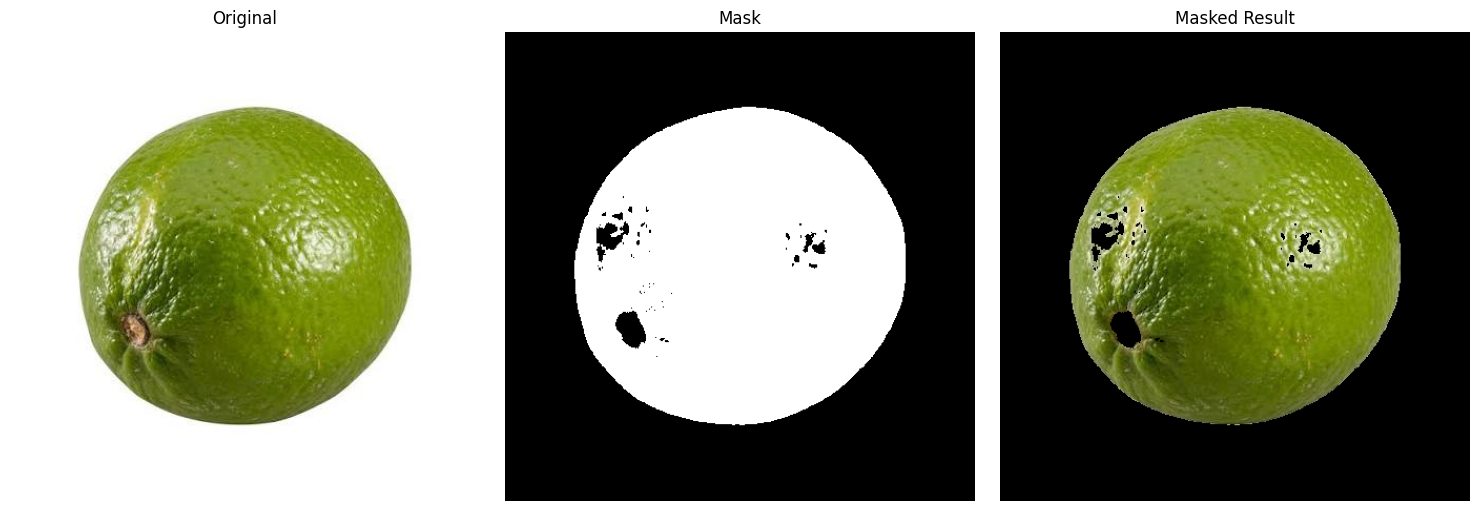

In [33]:
lime = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/lime.jpg')

lime_rgb = cv2.cvtColor(lime, cv2.COLOR_BGR2RGB)
lime_hsv = cv2.cvtColor(lime_rgb, cv2.COLOR_RGB2HSV)

lower_lime = np.array([25,50,50])
upper_lime = np.array([60,255,255])

mask_lime = cv2.inRange(lime_hsv, lower_lime, upper_lime)

result_mask_lime = cv2.bitwise_and(lime_rgb, lime_rgb, mask=mask_lime)

plot_images(images=[lime_rgb, mask_lime, result_mask_lime],
            titles=["Original", "Mask", "Masked Result"])

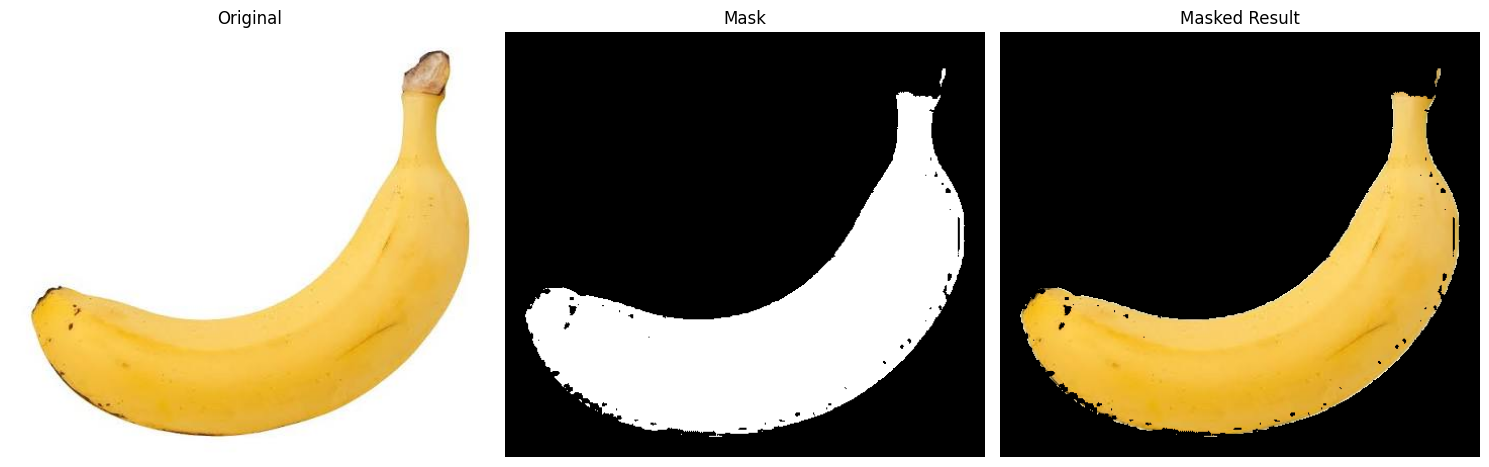

In [44]:
banana = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/banana.jpg')

banana_rgb = cv2.cvtColor(banana, cv2.COLOR_BGR2RGB)
banana_hsv = cv2.cvtColor(banana_rgb, cv2.COLOR_RGB2HSV)

# HSV Masking for banana
upper_banana = np.array([35,255,255])
lower_banana = np.array([20,50,50])

mask_banana = cv2.inRange(banana_hsv, lower_banana, upper_banana)

result_mask_banana = cv2.bitwise_and(banana_rgb, banana_rgb, mask=mask_banana)

plot_images(images=[banana_rgb, mask_banana, result_mask_banana],
            titles=["Original", "Mask", "Masked Result"])


5. Apply manual brightness/contrast to a dark banana image
(alpha=1.3, beta=20) using NumPy. Clip to [0,255] and convert to uint8. Compare
to cv2.convertScaleAbs()

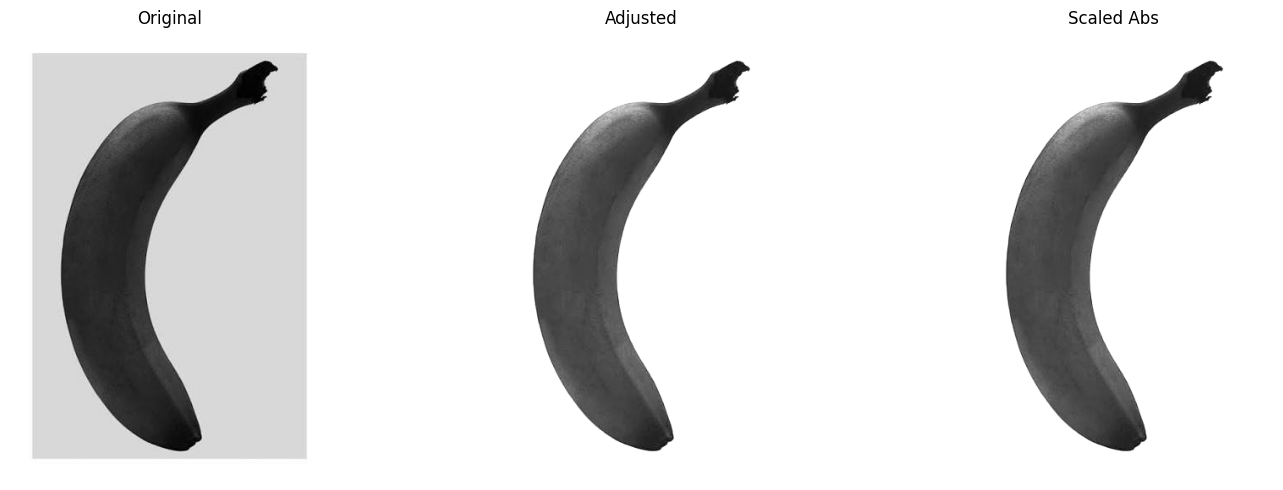

In [35]:
def adjust_brightness_contrast(img, alpha=1.3, beta=20):
    img_float = img.astype(np.float32)
    img_float = img_float * alpha + beta
    img_float = np.clip(img_float, 0, 255)
    return img_float.astype(np.uint8)

dark_banana = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/dark_banana.png')
dark_banana_rgb = cv2.cvtColor(dark_banana, cv2.COLOR_BGR2RGB)
banana_adjusted = adjust_brightness_contrast(dark_banana_rgb, alpha=1.3, beta=20)
banana_adjusted_abs = cv2.convertScaleAbs(dark_banana_rgb, alpha=1.3, beta=20)
plot_images(images=[dark_banana_rgb, banana_adjusted, banana_adjusted_abs ],
            titles=["Original", "Adjusted", "Scaled Abs"])

* Manual converting brightness/contrast is resulted same as using built in funciton of convertscaledabs.

* The dark image (banana) lights up and its not completely dark after the adjustment.

6.  Reflection: why does HSV work better than RGB for fruit
color segmentation? When would it fail? (Hint: try a very dark purple grape or
blueberry.)

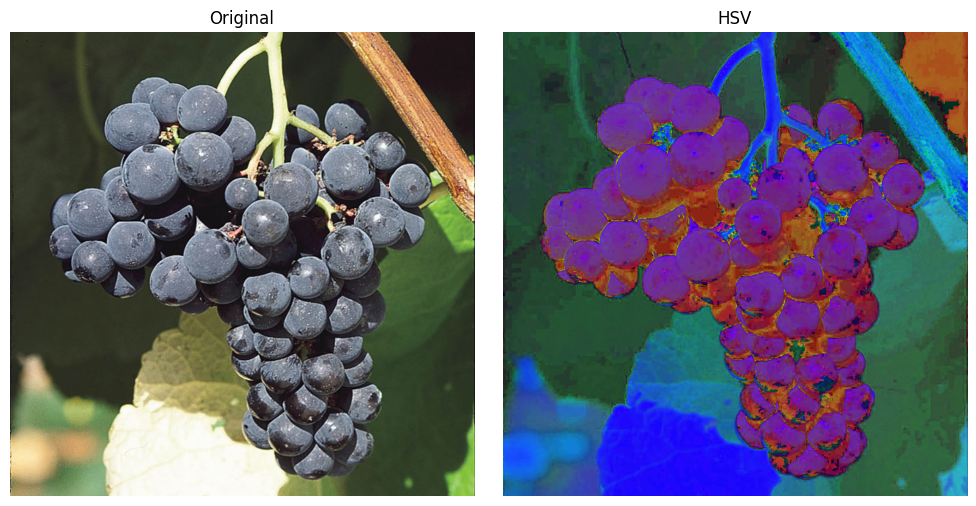

In [36]:
dark_purple_grape = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/dark_purple_grape.png')
dark_purple_grape_rgb = cv2.cvtColor(dark_purple_grape, cv2.COLOR_BGR2RGB)
dark_purple_grape_hsv = cv2.cvtColor(dark_purple_grape_rgb, cv2.COLOR_RGB2HSV)

plot_images(images=[dark_purple_grape_rgb,dark_purple_grape_hsv],
            titles=["Original", "HSV"])

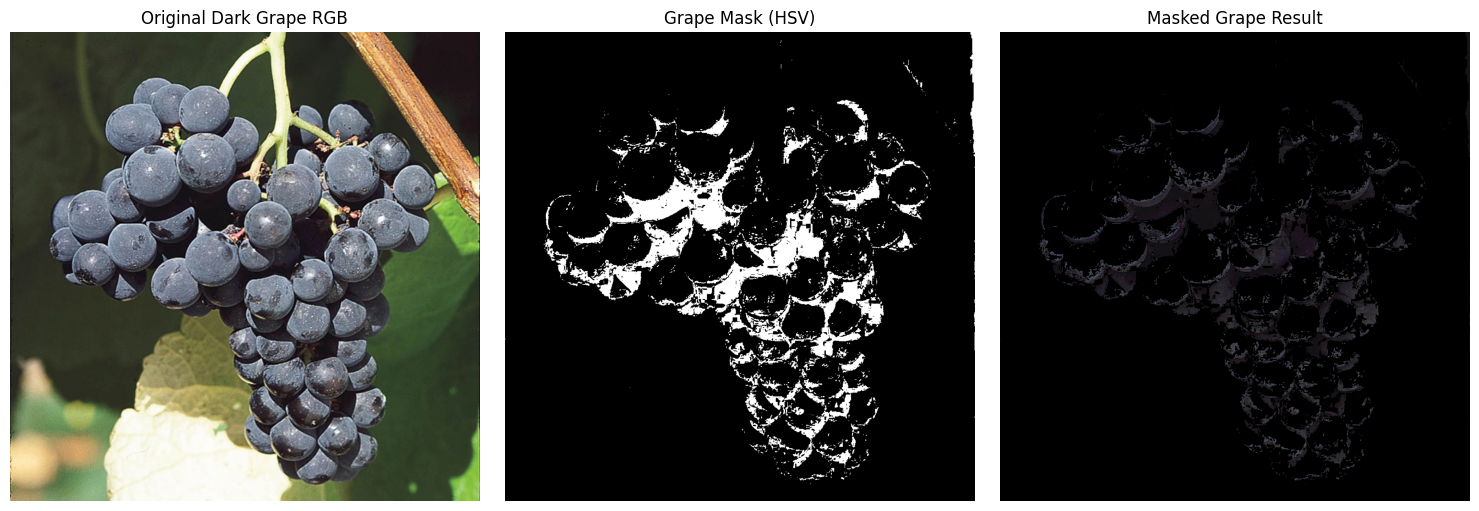

In [37]:
# Split the H, S, V channels from the dark purple grape HSV image
h_grape, s_grape, v_grape = cv2.split(dark_purple_grape_hsv)

# Let's try to define a range for dark purple/blue colors.
# This will be an estimation, as very dark colors make H and S less reliable.
# For purple, Hue typically falls in the range of ~120-160 (OpenCV scale 0-180).
# We'll need a low Value range for 'dark' and moderate Saturation.

# Adjust these values based on visual inspection if needed
# Lower bound for dark purple/blue
lower_grape_hsv = np.array([110, 20, 10]) # Hue, Saturation, Value
# Upper bound for dark purple/blue
upper_grape_hsv = np.array([160, 255, 100]) # Hue, Saturation, Value (limiting max V)

# Create the mask
mask_grape = cv2.inRange(dark_purple_grape_hsv, lower_grape_hsv, upper_grape_hsv)

# Apply the mask to the original RGB image
masked_grape_result = cv2.bitwise_and(dark_purple_grape_rgb, dark_purple_grape_rgb, mask=mask_grape)

# Display the results
plot_images(images=[dark_purple_grape_rgb, mask_grape, masked_grape_result],
            titles=["Original Dark Grape RGB", "Grape Mask (HSV)", "Masked Grape Result"],
            cmap='gray')

### Reflection: Why HSV for Color Segmentation?

1.  **Intuitive Color Representation:** HSV separates color information (Hue and Saturation) from intensity information (Value/Brightness). In contrast, RGB combines these aspects, meaning that a change in brightness will alter all three R, G, and B components. This makes defining color ranges in RGB much harder and less robust to lighting variations.

2.  **Robustness to Lighting:** Because Hue and Saturation are less affected by changes in light intensity than RGB components, HSV makes it easier to segment objects based purely on their color, even under different lighting conditions. For example, a red apple will generally have a consistent Hue value regardless of whether it's brightly lit or slightly shadowed, whereas its R, G, and B values would change significantly.

3.  **Simplified Thresholding:** In HSV, you can define a narrow range for Hue to target a specific color (e.g., green for green apples, yellow for bananas). Saturation helps to filter out gray or desaturated areas (like white backgrounds), and Value can help to include or exclude very dark/bright regions. This often leads to cleaner masks with simpler thresholding logic compared to complex multi-dimensional thresholding required in RGB.

### When HSV Segmentation Can Fail (e.g., Dark Purple Grape):

While powerful, HSV is not foolproof. It can struggle in certain scenarios, particularly with very dark or very bright colors:

1.  **Very Dark Colors (Low Value):** For extremely dark colors, such as in `dark_purple_grape.png`, the **Hue** and **Saturation** components become unstable or less meaningful. When the 'Value' (brightness) is very low, all colors tend to converge towards black. In these regions, a slight change in intensity can lead to a large, often erratic, shift in the Hue value. This makes it difficult to reliably distinguish between different dark colors based on their Hue or Saturation alone. The `dark_purple_grape` image demonstrates this: while the HSV representation might look visually distinct from the RGB, isolating a specific `purple` hue in a very dark context can still be challenging because the `H` and `S` values can be highly compressed and less discriminative when `V` is near zero.

2.  **Very Bright Colors (High Value):** Similarly, for very bright, near-white colors, saturation approaches zero, and hue also becomes ill-defined. All very bright colors tend to look white, and distinguishing between them based on hue is nearly impossible.

3.  **Color Overlap:** If two distinct objects in an image happen to have very similar Hue and Saturation values (e.g., a yellow banana against a yellow wall), even HSV will find it challenging to segment them solely based on color.

In summary, HSV excels because it aligns more closely with human color perception and separates chrominance from luminance. However, its performance degrades at the extremes of brightness, where Hue and Saturation information become ambiguous.

# Part B — Histograms & Filtering


1. Load strawberry.jpg as grayscale. Plot its histogram.

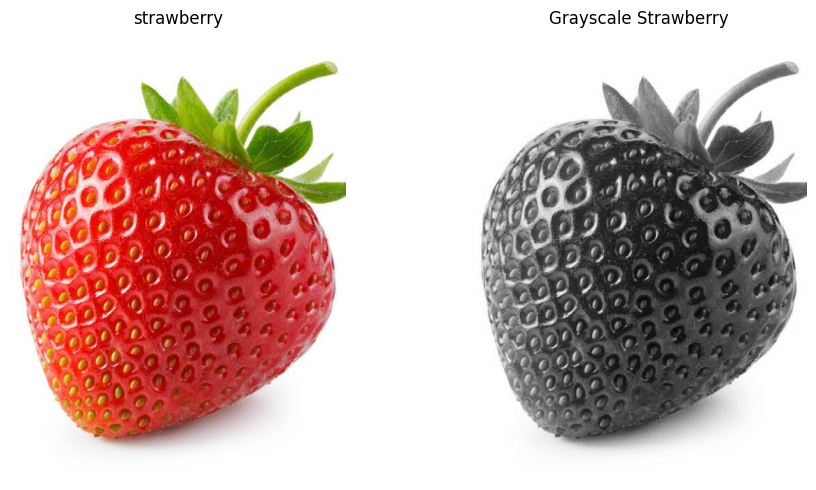

In [38]:
strawberry = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/strawberry.jpg')
strawberry_rbg = cv2.cvtColor(strawberry, cv2.COLOR_BGR2RGB)
strawberry_gray = cv2.cvtColor(strawberry, cv2.COLOR_BGR2GRAY)

plot_images(images=[strawberry_rbg,strawberry_gray],
            titles=["strawberry","Grayscale Strawberry"],
            cmap='gray')

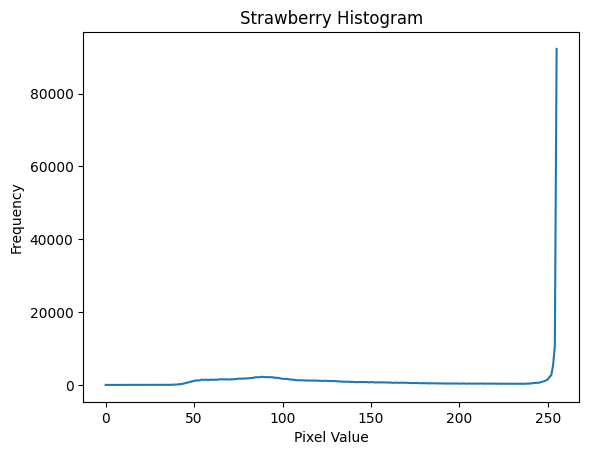

In [39]:
strawberry_hist = cv2.calcHist([strawberry_gray], [0], None, [256], [0,256])
# Plot strawberry histogram
plt.plot(strawberry_hist)
plt.title('Strawberry Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

Is the image well-exposed? What does the histogram shape tell you about
contrast?
> Image appears to be overexposed as its predominantly bright.

> Histogram shape shows the color intensity on strawberry lies on the lighter side (close to white). As the image was with white background and the strawberry itself lies cloer to higher end of red value closer to white.

*The histogram shows that most pixel values are concentrated towards the lighter side, especially with a large peak at the far right, which corresponds to the white background. The strawberry itself also contributes to the brighter end of the spectrum due to its vivid color.*


2. Apply global histogram equalization
(cv2.equalizeHist()). Then apply CLAHE with clipLimit=2.0 and clipLimit=8.0.
Show all four versions side by side (original, equalized, CLAHE-2, CLAHE-8).

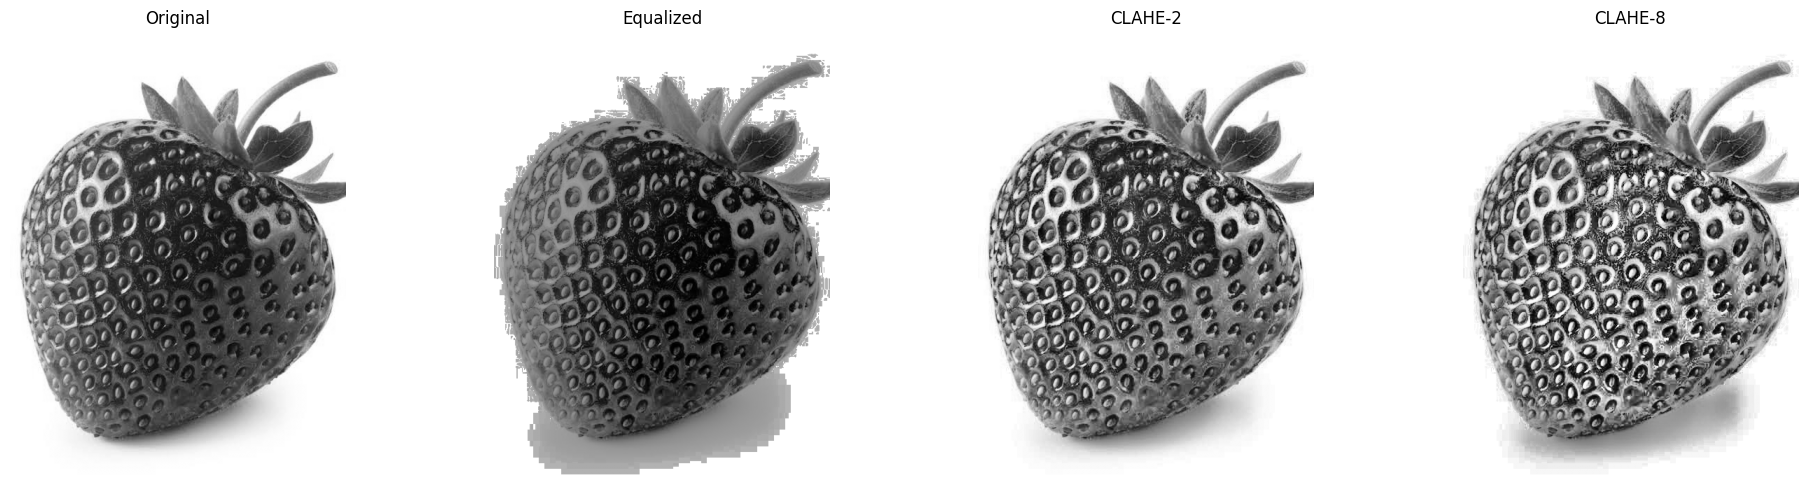

In [40]:
strawberry_eq = cv2.equalizeHist(strawberry_gray)

clahe_2 = cv2.createCLAHE(clipLimit=2.0)
strawberry_clahe_2 = clahe_2.apply(strawberry_gray)
clahe_8 = cv2.createCLAHE(clipLimit=8.0)
strawberry_clahe_8 = clahe_8.apply(strawberry_gray)

plot_images(images=[strawberry_gray, strawberry_eq, strawberry_clahe_2, strawberry_clahe_8],
            titles=["Original", "Equalized", "CLAHE-2", "CLAHE-8"])

Which helps the HSV segmentation mask most?
> Equalized contains noise on the edges and blurness.
>
> CLAHE 2, CLAHE 8 both has no noise and clear pixel intensity.
> > CHAHE 2 has more abstract image with slight intensity where as in CLAHE 8, the intensity is high (due to high cliplimit which helps to aggressive contrast stretching), this might help HSV segmentation mask most.

3. Noise experiment: add Gaussian noise (mean=0, std=25)
to orange.jpg using np.random.normal(). Apply Gaussian blur, median filter, and
bilateral filter. Which removes the noise best while keeping the fruit’s edge
sharp? Plot all four for comparison.

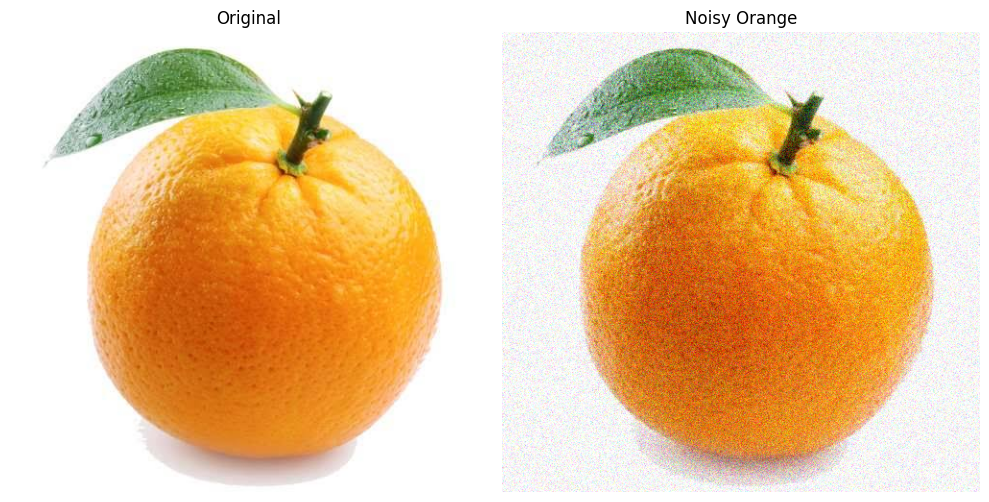

In [41]:
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

orange = cv2.imread("/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/orange.png")
assert orange is not None, "file could not be read, check with os.path.exists()"

orange_rbg = cv2.cvtColor(orange, cv2.COLOR_BGR2RGB)

orange_noise = add_gaussian_noise(orange_rbg, mean=0, std=25)
# orange_noise = cv2.cvtColor(orange_noise, cv2.COLOR_RGB2BGR)

plot_images(images=[orange_rbg, orange_noise],
            titles=["Original", "Noisy Orange"])

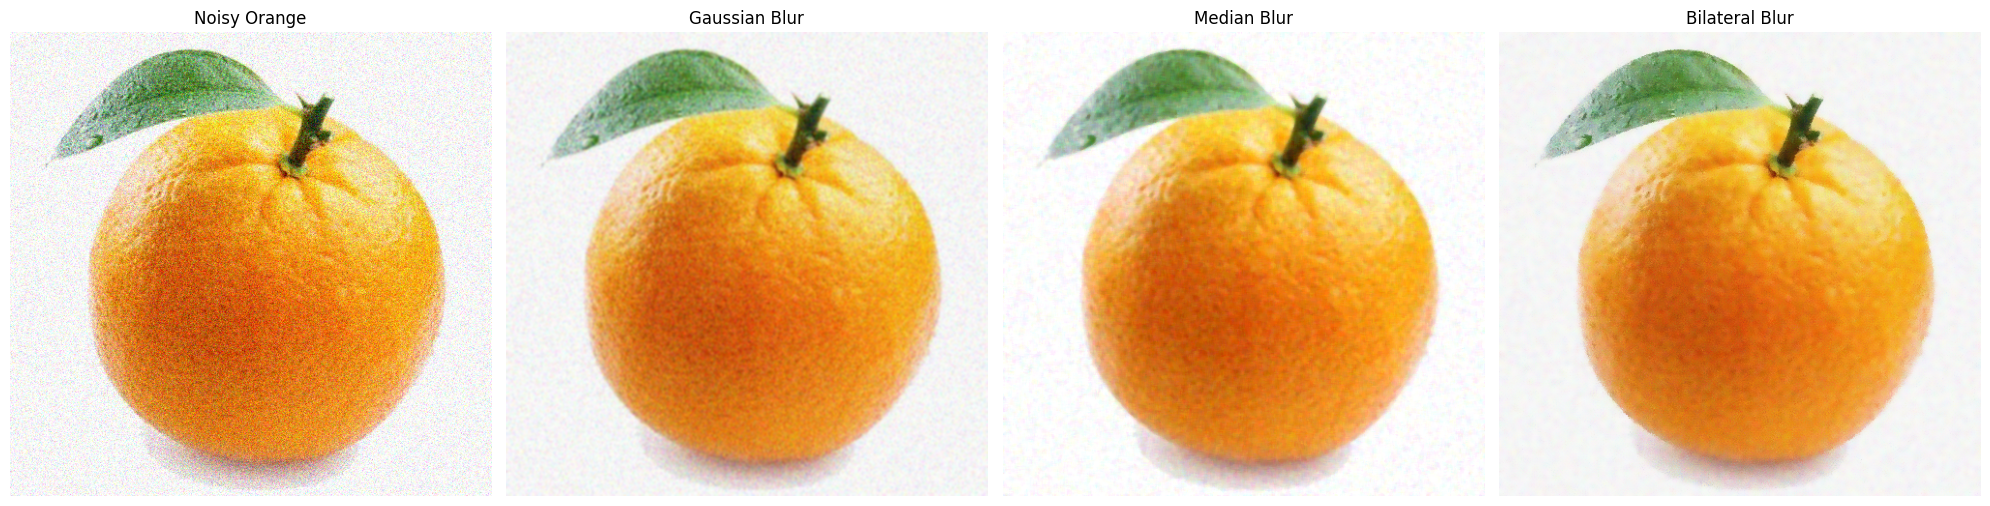

In [42]:
orange_gaussian_blur = cv2.GaussianBlur(orange_noise, ksize=(5,5), sigmaX=0)
orange_median_blur = cv2.medianBlur(orange_noise, ksize=5)
orange_bilateral_blur = cv2.bilateralFilter(orange_noise, d=9, sigmaColor=75, sigmaSpace=75)

plot_images(images=[orange_noise, orange_gaussian_blur, orange_median_blur, orange_bilateral_blur],
            titles=["Noisy Orange", "Gaussian Blur", "Median Blur", "Bilateral Blur"])

* Gaussian Blur is effective at noise reduction but at the cost of significant edge blurring.
* Median Blur does a good job of both removing noise and preserving edges. It's often a strong performer for this kind of task, especially against impulse noise.
* Bilateral Filter often offers the best trade-off for edge preservation while reducing noise. It typically removes noise more subtly than median blur in textured areas and preserves the sharpness of the fruit's edges even better than the median filter, which can sometimes slightly flatten details.

For this specific image, while median blur is very good, the Bilateral Filter appears to be slightly superior in retaining the sharpness of the orange's texture and edges while still effectively diminishing the noise.

4.  Extended — manual convolution: implement conv2d() from
scratch. Apply a Sobel X kernel to the grayscale banana image. Compare to
cv2.filter2D(). What is the mean absolute difference? Explain any discrepancy.


--- Sobel X Filter Comparison ---


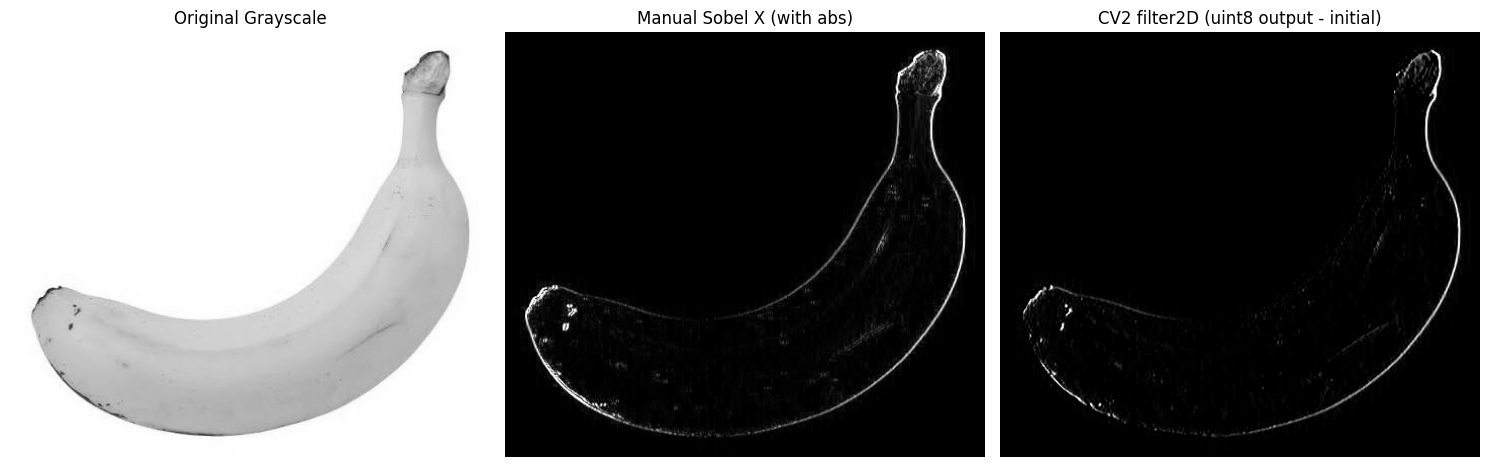

Mean Absolute Difference (Manual vs Initial CV2 filter2D): 2.41
Note: The initial CV2 filter2D output directly to uint8, clipping negative gradients, hence the difference.


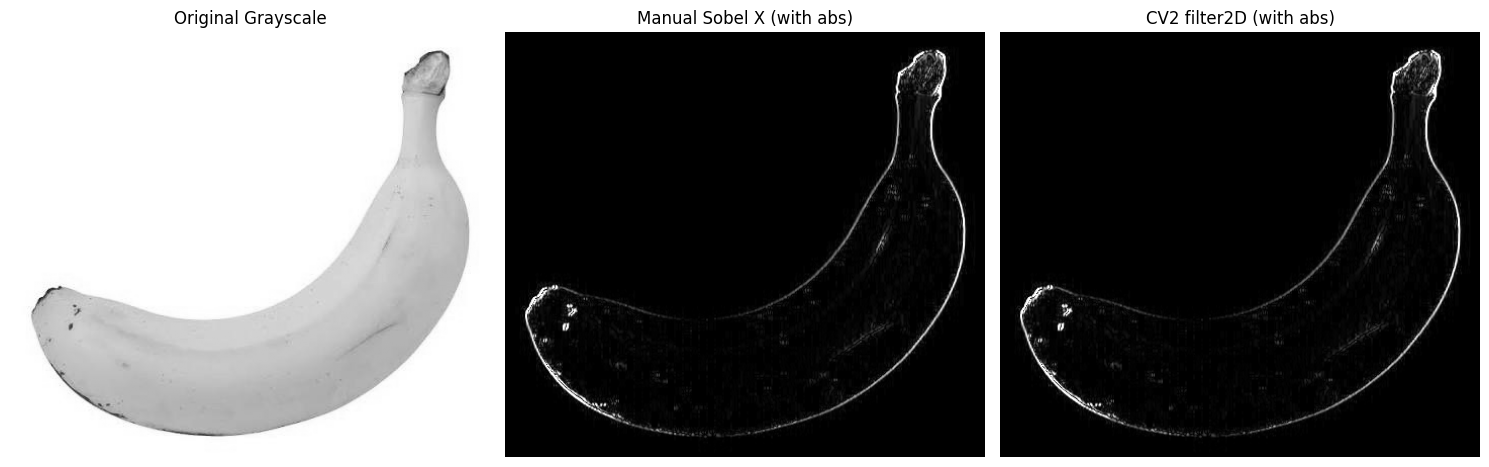

Mean Absolute Difference (Manual vs CV2 filter2D): 0.00


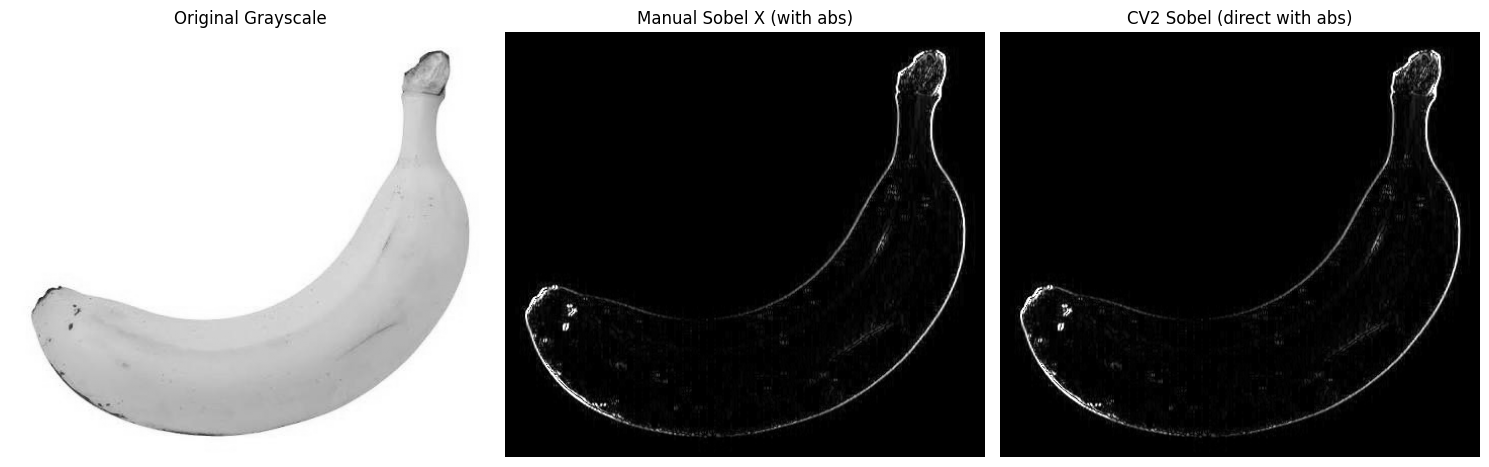

Mean Absolute Difference (Manual vs CV2 Sobel direct): 0.00


In [60]:
def manual_sobel_x(image):
    """
    Applies a manual Sobel X filter to an image.
    Converts to grayscale, calculates horizontal gradients, takes absolute value,
    clips, and converts to uint8.
    """
    # 1. Convert to grayscale and floating point for gradient math
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    gray = gray.astype(np.float32)
    h, w = gray.shape
    output = np.zeros_like(gray)

    # 2. Define the Sobel X kernel
    kernel_x = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=np.float32)

    # 3. Perform 2D convolution (skipping the 1-pixel border for simplicity)
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            # Extract the 3x3 local neighborhood region
            receptive_field = gray[y-1:y+2, x-1:x+2]

            # Element-wise multiply and sum up the products
            gradient_x = np.sum(receptive_field * kernel_x)

            # Store the absolute value to map both positive and negative transitions
            output[y, x] = abs(gradient_x)

    # 4. Clip and convert back to 8-bit unsigned integer format
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

def demonstrate_sobel_comparison(original_banana_bgr_image):
    """
    Demonstrates and compares manual Sobel X implementation with OpenCV's
    cv2.filter2D and cv2.Sobel, correctly handling absolute values.
    """
    print("\n--- Sobel X Filter Comparison ---")

    # Convert original BGR image to grayscale for Sobel operations
    banana_gray = cv2.cvtColor(original_banana_bgr_image, cv2.COLOR_BGR2GRAY)

    # --- 1. Manual Sobel X Implementation ---
    banana_sobel_manual = manual_sobel_x(banana_gray)

    # --- 2. OpenCV's cv2.filter2D  ---
    banana_cv2_filter_initial = cv2.filter2D(banana_gray, -1, np.array([[-1, 0, 1],
                                                                        [-2, 0, 2],
                                                                        [-1, 0, 1]], dtype=np.float32))

    plot_images(images=[banana_gray, banana_sobel_manual, banana_cv2_filter_initial],
                titles=["Original Grayscale", "Manual Sobel X (with abs)", "CV2 filter2D (uint8 output - initial)"])
    initial_mad = np.mean(np.abs(banana_sobel_manual - banana_cv2_filter_initial))
    print(f"Mean Absolute Difference (Manual vs Initial CV2 filter2D): {initial_mad:.2f}")
    print("Note: The initial CV2 filter2D output directly to uint8, clipping negative gradients, hence the difference.")

    # --- 3. OpenCV's cv2.filter2D (corrected with absolute values) ---
    kernel_x = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=np.float32)

    # Apply cv2.filter2D with a floating-point output depth to preserve negative values
    banana_cv2_filter_float = cv2.filter2D(src=banana_gray, ddepth=cv2.CV_64F, kernel=kernel_x)
    # Convert to absolute values and then to uint8 for visualization
    banana_cv2_filter_abs = cv2.convertScaleAbs(banana_cv2_filter_float)

    plot_images(images=[banana_gray, banana_sobel_manual, banana_cv2_filter_abs],
                titles=["Original Grayscale", "Manual Sobel X (with abs)", "CV2 filter2D (with abs)"])

    # Calculate and print the new Mean Absolute Difference
    mean_abs_diff_corrected = np.mean(np.abs(banana_sobel_manual - banana_cv2_filter_abs))
    print(f"Mean Absolute Difference (Manual vs CV2 filter2D): {mean_abs_diff_corrected:.2f}")

    # --- 4. OpenCV's cv2.Sobel (direct function with absolute values) ---
    # Using cv2.Sobel directly, specifying dx=1 (X-gradient), dy=0 (no Y-gradient)
    sobelx_cv2 = cv2.Sobel(src=banana_gray, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=3)
    sobelx_cv2_abs = cv2.convertScaleAbs(sobelx_cv2)

    plot_images(images=[banana_gray, banana_sobel_manual, sobelx_cv2_abs],
                titles=["Original Grayscale", "Manual Sobel X (with abs)", "CV2 Sobel (direct with abs)"])

    mean_abs_diff_sobel_direct = np.mean(np.abs(banana_sobel_manual - sobelx_cv2_abs))
    print(f"Mean Absolute Difference (Manual vs CV2 Sobel direct): {mean_abs_diff_sobel_direct:.2f}")

# Assuming 'banana' variable is loaded from previous cells as the BGR banana image
demonstrate_sobel_comparison(banana)

The mean absoulte difference for manual vs filter2d, & cv2 sobel direct is zero after abs. The initial CV2 filter2D output directly to uint8, clipping negative gradients, hence the difference seen on first (when used ddepth of -1) which created a loss of information. No discrepency seen.
